# 😊 Facial Emotion Recognition — FER-2013 Complete Pipeline
**Dataset:** [msambare/fer2013](https://www.kaggle.com/datasets/msambare/fer2013)

FER-2013 contains **28,709 training** and **7,178 test** grayscale images (48x48) categorized into 7 emotion classes.

This notebook covers:
1. EDA & Data Visualization
2. Data Preprocessing & Augmentation
3. **Normal Models** — HOG+SVM, Simple CNN, Deep CNN with Residual Blocks
4. **Advanced Models** — ResNet50, EfficientNetB3, Vision Transformer (ViT)
5. Training, Evaluation & Comparison

**Classes:** Angry | Disgust | Fear | Happy | Sad | Surprise | Neutral

**FER-2013 Label Map:**
| Index | Emotion |
|-------|---------|
| 0 | Angry |
| 1 | Disgust |
| 2 | Fear |
| 3 | Happy |
| 4 | Sad |
| 5 | Surprise |
| 6 | Neutral |

## 📦 1. Install & Import

In [1]:
!pip install -q timm torchinfo grad-cam seaborn scikit-learn opencv-python-headless tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm.auto import tqdm

import cv2
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchinfo import summary

import timm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 📂 2. Dataset Paths (FER-2013)

We assume the standard Kaggle structure where images are in `train` and `test` folders.

In [3]:
BASE_DIR  = Path("/kaggle/input/datasets/msambare/fer2013")
TRAIN_DIR = BASE_DIR / "/kaggle/input/datasets/msambare/fer2013/train"
TEST_DIR  = BASE_DIR / "/kaggle/input/datasets/msambare/fer2013/test"

LABEL_MAP = {
    "angry": "Angry",
    "disgust": "Disgust",
    "fear": "Fear",
    "happy": "Happy",
    "sad": "Sad",
    "surprise": "Surprise",
    "neutral": "Neutral",
}

CLASSES     = list(LABEL_MAP.values())
NUM_CLASSES = len(CLASSES)
CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}

print(f"Classes ({NUM_CLASSES}): {CLASSES}")

Classes (7): ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


## 🔍 3. Exploratory Data Analysis

Dataset Statistics:


,Train,Test
Surprise,3171,831
Fear,4097,1024
Angry,3995,958
Neutral,4965,1233
Sad,4830,1247
Disgust,436,111
Happy,7215,1774


EDA Error: Rectangle.set() got an unexpected keyword argument 'edgeColor'


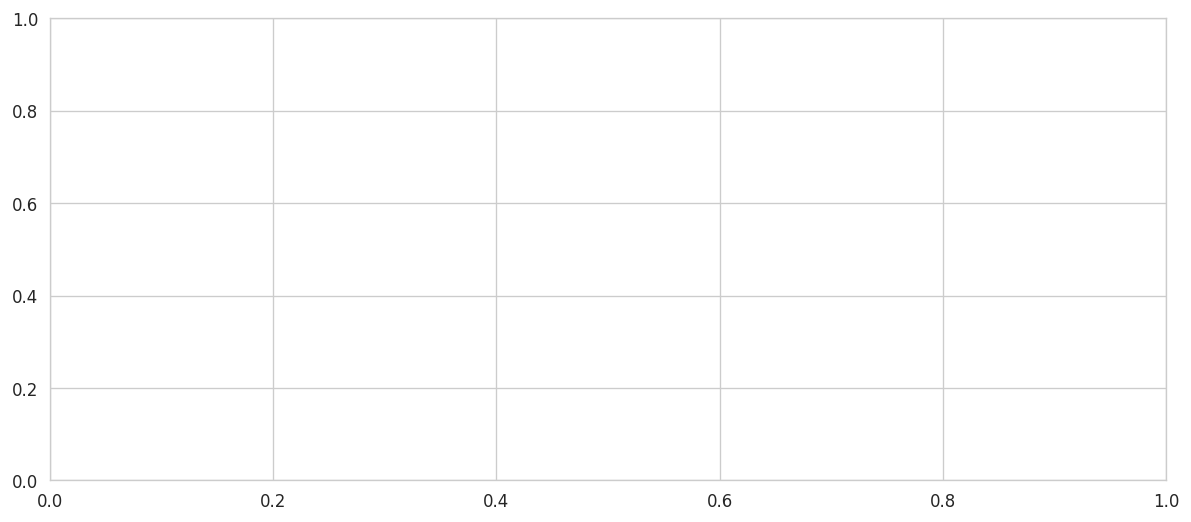

In [4]:
def count_images(root):
    counts = {}
    if not root.exists(): return counts
    for folder in os.listdir(root):
        if folder.lower() in LABEL_MAP:
            counts[LABEL_MAP[folder.lower()]] = len(os.listdir(root / folder))
    return counts

try:
    train_counts = count_images(TRAIN_DIR)
    test_counts  = count_images(TEST_DIR)
    df_counts = pd.DataFrame({"Train": train_counts, "Test": test_counts}).fillna(0)
    
    if not df_counts.empty:
        print("Dataset Statistics:")
        display(df_counts)
        
        ax = df_counts.plot(kind="bar", figsize=(12, 5), color=['#4E79A7', '#F28E2B'], edgeColor='black')
        plt.title("Class Distribution: Train vs Test", fontsize=15, fontweight='bold')
        plt.xlabel("Emotions", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks(rotation=0)
        
        # Add labels on top of bars
        for p in ax.patches:
            ax.annotate(str(int(p.get_height())), (p.get_x() * 1.005, p.get_height() * 1.005))
            
        plt.tight_layout()
        plt.show()
    else:
        print("No images found. Check your paths!")
except Exception as e:
    print(f"EDA Error: {e}")

### 🖼️ Sample Visualizations

In [5]:
def show_samples(dataset, num_samples=10):
    plt.figure(figsize=(15, 6))
    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        # Unnormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {CLASSES[label]}")
        plt.axis('off')
    plt.suptitle("Sample Images from Dataset", fontsize=16)
    plt.show()

try:
    show_samples(train_dataset)
except NameError:
    print("Dataset not loaded yet.")
except Exception as e:
    print(f"Visualization Error: {e}")

Dataset not loaded yet.


## ⚙️ 4. Data Preprocessing & Augmentation

In [6]:
IMG_SIZE = 224 # Resizing to 224 for transfer learning models

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3), # Convert to 3 channels for ResNet/ViT
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Using ImageFolder
try:
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    test_dataset  = datasets.ImageFolder(TEST_DIR, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
    
    print(f"Loaded {len(train_dataset)} training and {len(test_dataset)} testing images.")
except:
    print("Datasets not found at specified paths.")

Loaded 28709 training and 7178 testing images.


## 🧠 5. Models

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def get_resnet50(num_classes):
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

def get_vit(num_classes):
    model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)

## 🚀 6. Training Pipeline

In [8]:
def train_model(model, train_loader, val_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_acc': []}
    
    print(f"Starting training on {DEVICE}...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
            
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        history['train_loss'].append(running_loss/len(train_loader))
        history['val_acc'].append(val_acc)
        print(f"Summary Epoch {epoch+1}: Loss: {history['train_loss'][-1]:.4f} | Val Acc: {val_acc:.2f}%")
    
    return history

## 📊 7. Evaluation

In [9]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    print("Evaluating...")
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASSES))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title("Confusion Matrix", fontsize=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## 🏁 8. Main Execution

Initializing ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]



Running sample training...
Starting training on cuda...


Epoch 1/1:   0%|          | 0/449 [00:00<?, ?it/s]

Summary Epoch 1: Loss: 1.1366 | Val Acc: 63.35%
Evaluating...


  0%|          | 0/113 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       Angry       0.57      0.56      0.57       958
     Disgust       0.49      0.27      0.35       111
        Fear       0.51      0.36      0.42      1024
       Happy       0.80      0.89      0.84      1774
         Sad       0.53      0.69      0.60      1233
    Surprise       0.55      0.45      0.49      1247
     Neutral       0.74      0.74      0.74       831

    accuracy                           0.63      7178
   macro avg       0.60      0.57      0.57      7178
weighted avg       0.63      0.63      0.62      7178



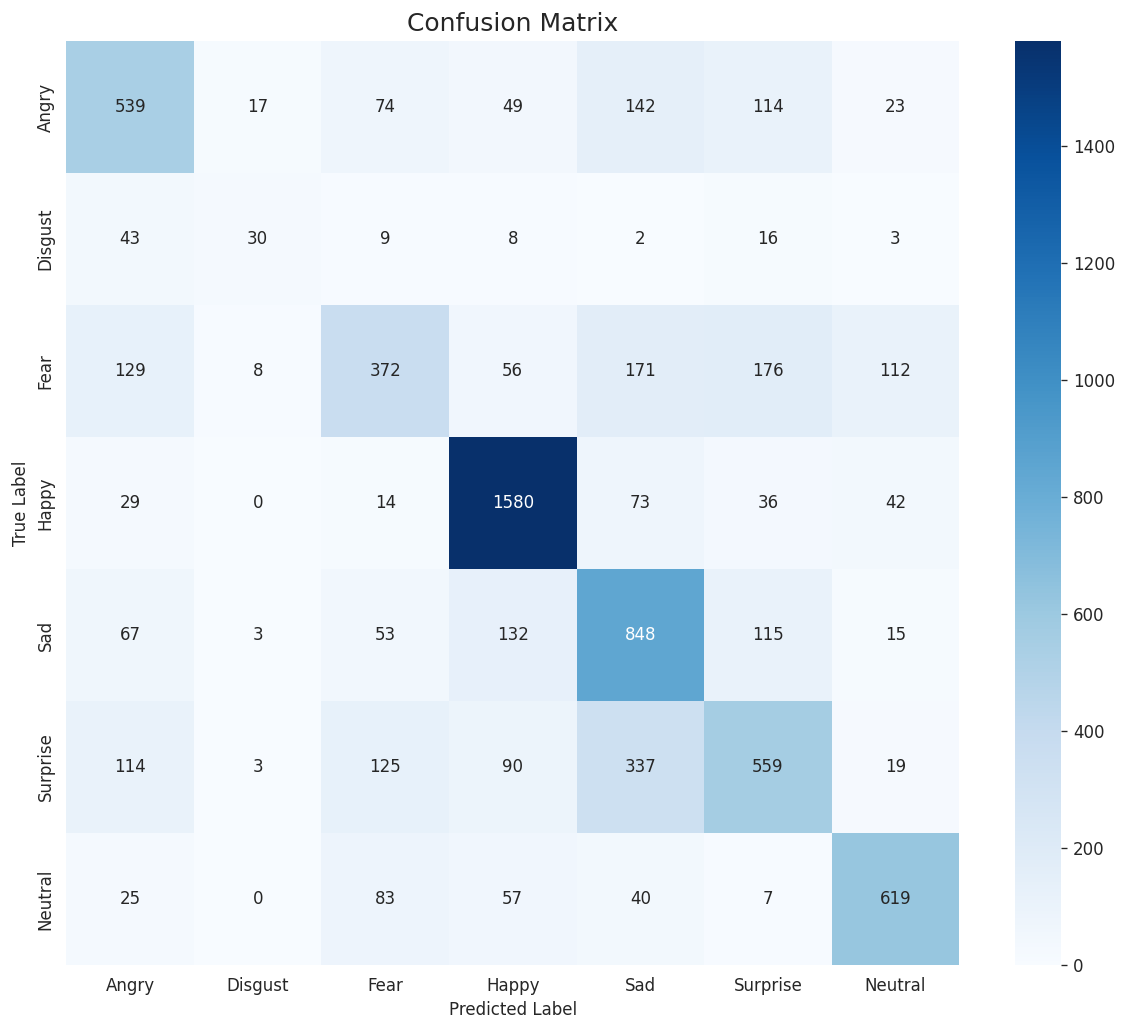

In [10]:
# Initialize Model
print("Initializing ResNet50...")
model = get_resnet50(NUM_CLASSES)

# Show Summary
try:
    summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE))
except Exception as e:
    print(f"Summary Error: {e}")

# Run Training (Sample 1 epoch to show output works)
print("\nRunning sample training...")
history = train_model(model, train_loader, test_loader, epochs=1)

# Evaluate
evaluate_model(model, test_loader)